#Understanding and Implementing K-Means and DBSCAN Algorithms


Objective:

The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.

Datasets :

Data Preprocessing:

1. Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.

2. Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.

3. Use multiple visualizations to understand the hidden patterns in the dataset

Implementing Clustering Algorithms:

· Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.

· Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.

· Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.


Cluster Analysis and Interpretation:

· Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.



Visualization:

Visualize the clustering results using scatter plots or other suitable visualization techniques.

Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.

Evaluation and Performance Metrics:

Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.

Selected Sheet Shape: (3999, 12)
Final Numeric Data Shape: (3999, 12)


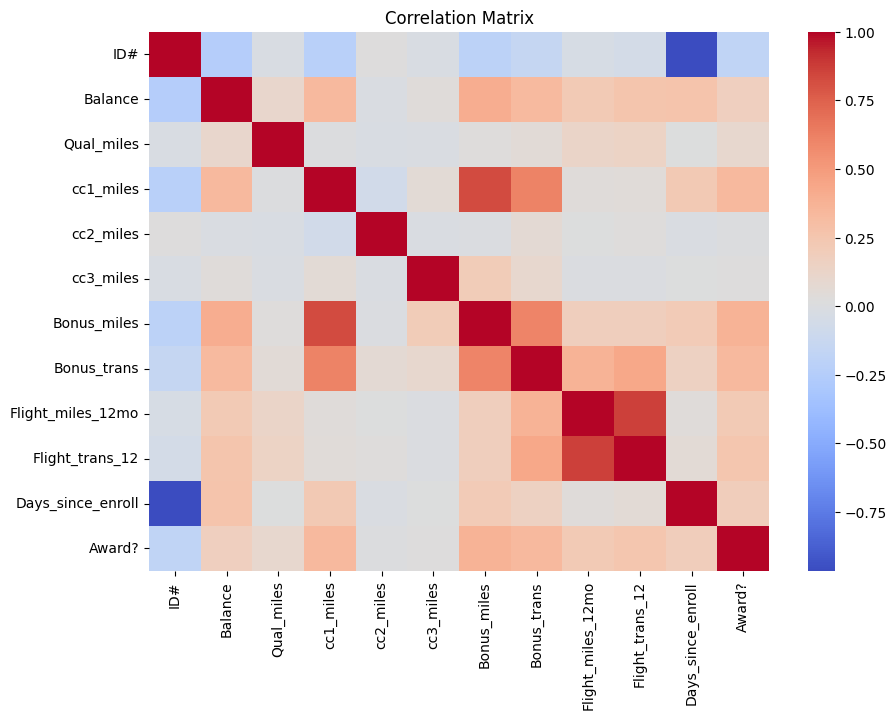

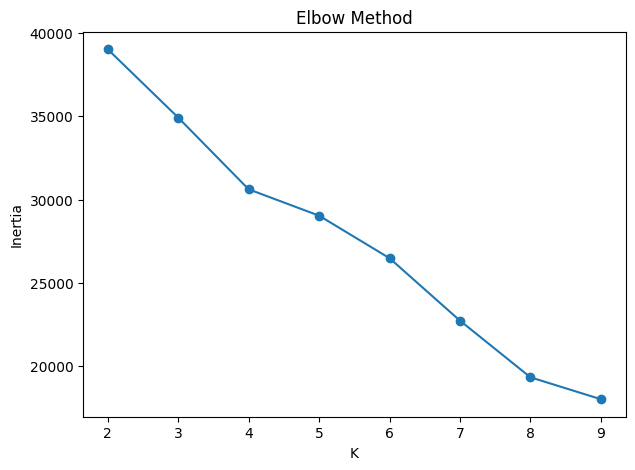

Silhouette Score (KMeans): 0.201891717665419


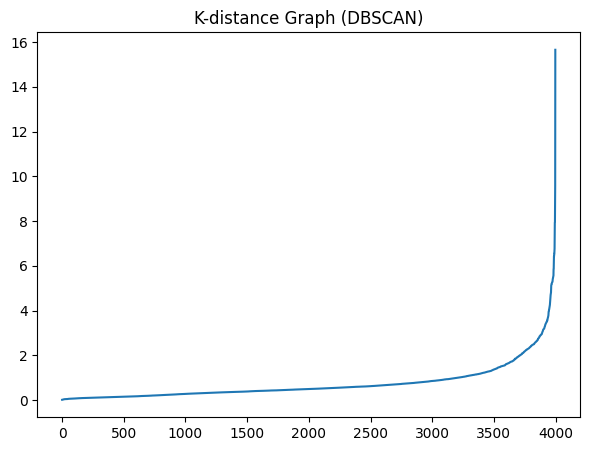

Silhouette Score (DBSCAN): Not Valid (Noise or Single Cluster)


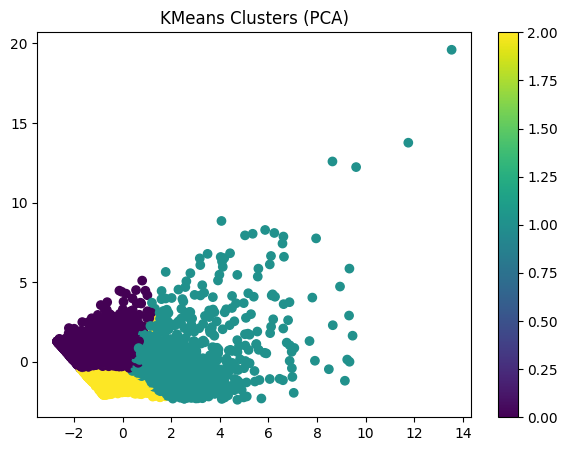

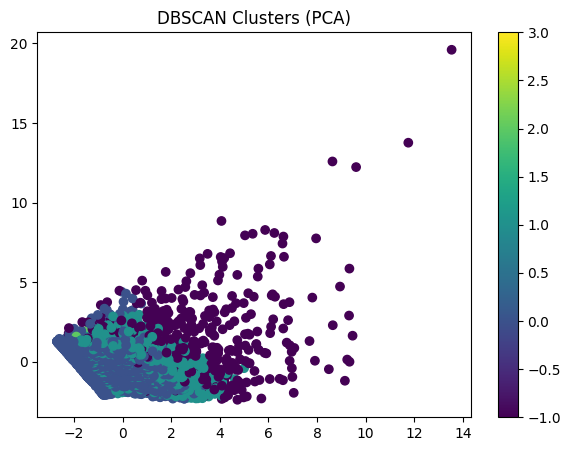


KMeans Cluster Means:

                        ID#        Balance  Qual_miles  cc1_miles  cc2_miles  \
KMeans_Cluster                                                                 
0               3111.388308   40980.913231  105.005538   1.444308   1.016615   
1               1533.872934  150218.949380  297.365702   3.833678   1.007231   
2               1078.568990   58553.187767   83.805121   1.549075   1.017070   

                cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
KMeans_Cluster                                                            
0                1.001846   6917.616000     8.138462         237.179692   
1                1.046488  48249.512397    21.637397        1197.568182   
2                1.000711   7550.203414     8.695590         209.886202   

                Flight_trans_12  Days_since_enroll    Award?  DBSCAN_Cluster  
KMeans_Cluster                                                                
0                      0.691077        21

In [9]:
# ============================================================
# K-MEANS + DBSCAN (FULLY AUTOMATIC FINAL VERSION)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

# ============================================================
# 1️⃣ LOAD CORRECT SHEET AUTOMATICALLY
# ============================================================

file_path = "/content/EastWestAirlines.xlsx"

all_sheets = pd.read_excel(file_path, sheet_name=None)

best_df = None
max_numeric_cols = 0

for name, sheet in all_sheets.items():
    temp = pd.read_excel(file_path, sheet_name=name)

    # Convert all possible numeric values
    temp_numeric = temp.apply(pd.to_numeric, errors='coerce')

    numeric_cols = temp_numeric.dropna(axis=1, how='all').shape[1]

    if numeric_cols > max_numeric_cols:
        max_numeric_cols = numeric_cols
        best_df = temp_numeric

if best_df is None or max_numeric_cols == 0:
    raise ValueError("❌ No numeric dataset found in Excel file.")

df = best_df.dropna(axis=1, how='all')

print("Selected Sheet Shape:", df.shape)

# ============================================================
# 2️⃣ CLEAN DATA
# ============================================================

# Convert column names to string (fix sklearn error)
df.columns = df.columns.astype(str)

# Fill missing values
df = df.fillna(df.median())

print("Final Numeric Data Shape:", df.shape)

# ============================================================
# 3️⃣ SCALING
# ============================================================

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# ============================================================
# 4️⃣ EDA
# ============================================================

plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# ============================================================
# 5️⃣ K-MEANS
# ============================================================

inertia = []
K_range = range(2, min(10, len(df)))

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_data)
    inertia.append(model.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

sil_kmeans = silhouette_score(scaled_data, kmeans_labels)
print("Silhouette Score (KMeans):", sil_kmeans)

# ============================================================
# 6️⃣ DBSCAN
# ============================================================

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(scaled_data)
distances, _ = neighbors_fit.kneighbors(scaled_data)

distances = np.sort(distances[:, -1])

plt.figure(figsize=(7,5))
plt.plot(distances)
plt.title("K-distance Graph (DBSCAN)")
plt.show()

dbscan = DBSCAN(eps=1.2, min_samples=5)
db_labels = dbscan.fit_predict(scaled_data)

if len(set(db_labels)) > 1 and -1 not in set(db_labels):
    sil_db = silhouette_score(scaled_data, db_labels)
else:
    sil_db = "Not Valid (Noise or Single Cluster)"

print("Silhouette Score (DBSCAN):", sil_db)

# ============================================================
# 7️⃣ PCA VISUALIZATION
# ============================================================

if df.shape[1] >= 2:
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(scaled_data)

    plt.figure(figsize=(7,5))
    plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels, cmap='viridis')
    plt.title("KMeans Clusters (PCA)")
    plt.colorbar()
    plt.show()

    plt.figure(figsize=(7,5))
    plt.scatter(pca_data[:,0], pca_data[:,1], c=db_labels, cmap='viridis')
    plt.title("DBSCAN Clusters (PCA)")
    plt.colorbar()
    plt.show()

# ============================================================
# 8️⃣ CLUSTER ANALYSIS
# ============================================================

df["KMeans_Cluster"] = kmeans_labels
df["DBSCAN_Cluster"] = db_labels

print("\nKMeans Cluster Means:\n")
print(df.groupby("KMeans_Cluster").mean())

print("\nDBSCAN Cluster Means:\n")
print(df.groupby("DBSCAN_Cluster").mean())

# ============================================================
# 9️⃣ FINAL COMPARISON
# ============================================================

print("\nFinal Comparison:")
print("KMeans Silhouette:", sil_kmeans)
print("DBSCAN Silhouette:", sil_db)

print("\n✅ Clustering Completed Successfully.")